# Changan 300-vehicle raw telemetry

This notebook lists the 300 vehicle files inside the split archive, streams the first 20,000 rows of one vehicle without unpacking the archive, and plots pack voltage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('changan')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('changan')
display(released)

,unit,member,volume,offset
0,vin1,RAW_DATA/vin1.rar,raw/RAW_DATA.z01,43
1,vin2,RAW_DATA/vin2.rar,raw/RAW_DATA.z01,27248451651
2,vin3,RAW_DATA/vin3.rar,raw/RAW_DATA.zip,2162563023
3,vin4,RAW_DATA/vin4.rar,raw/RAW_DATA.zip,5939191784
4,vin5,RAW_DATA/vin5.rar,raw/RAW_DATA.zip,8063335470
...,...,...,...,...
295,vin296,RAW_DATA/vin296.rar,raw/RAW_DATA.zip,1061321037
296,vin297,RAW_DATA/vin297.rar,raw/RAW_DATA.zip,1441322873
297,vin298,RAW_DATA/vin298.rar,raw/RAW_DATA.zip,1702909559
298,vin299,RAW_DATA/vin299.rar,raw/RAW_DATA.zip,1964913136


Each row is one vehicle RAR inside the two-volume split zip, with the volume and byte offset where it starts.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('changan', unit='vin3', nrows=20000)
print(frame.shape)
display(frame.head())

(20000, 13)


,terminaltime,soc,speed,totalodometer,chargestatus,totalvoltage,totalcurrent,minvoltagebattery,maxvoltagebattery,mintemperaturevalue,maxtemperaturevalue,batteryvoltage,probetemperatures
0,57.0,65.0,5.0,8.4,3.0,367.1,0.0,3.818,3.828,18.0,20.0,3.823~3.823~3.824~3.824~3.824~3.823~3.823~3.82...,19.0~20.0~20.0~19.0~20.0~19.0~19.0~19.0~20.0~2...
1,14085515.0,63.0,0.0,10.0,3.0,363.9,6.1,3.768,3.798,21.0,23.0,3.79~3.79~3.791~3.792~3.792~3.792~3.791~3.795~...,23.0~23.0~23.0~23.0~23.0~23.0~23.0~22.0~23.0~2...
2,14085525.0,0.0,0.0,10.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,NaN,NaN
3,14085535.0,62.0,0.0,10.0,3.0,363.8,6.5,3.769,3.797,21.0,23.0,3.789~3.789~3.79~3.79~3.791~3.791~3.79~3.794~3...,23.0~23.0~23.0~23.0~23.0~23.0~22.0~22.0~23.0~2...
4,14085545.0,62.0,2.1,10.0,3.0,363.6,9.0,3.766,3.795,21.0,23.0,3.787~3.787~3.788~3.788~3.789~3.789~3.788~3.79...,23.0~23.0~23.0~23.0~23.0~23.0~23.0~22.0~23.0~2...


The rows are 10 s telemetry as released. `terminaltime` is a relative clock with no calendar date, and the per-cell voltages arrive as one `~`-separated string of 96 values.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['terminaltime', 'soc', 'totalvoltage', 'totalcurrent', 'minvoltagebattery', 'maxvoltagebattery']].describe().T)

,count,mean,std,min,25%,50%,75%,max
terminaltime,20000.0,4.256117e+07,8.930571e+06,57.0,4.138886e+07,4.683061e+07,4.691204e+07,4.698020e+07
soc,19642.0,5.538662e+01,2.728577e+01,0.0,3.400000e+01,5.600000e+01,7.900000e+01,1.270000e+02
totalvoltage,19642.0,3.567691e+02,5.723250e+01,0.0,3.494000e+02,3.595000e+02,3.800000e+02,4.041000e+02
totalcurrent,19642.0,-2.487853e+00,4.741270e+01,-1000.0,0.000000e+00,1.700000e+00,8.300000e+00,1.874000e+02
minvoltagebattery,19642.0,3.692762e+00,5.901764e-01,0.0,3.630000e+00,3.719000e+00,3.926000e+00,4.169000e+00
maxvoltagebattery,19642.0,3.723714e+00,5.976365e-01,0.0,3.644000e+00,3.754000e+00,3.967000e+00,4.220000e+00


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

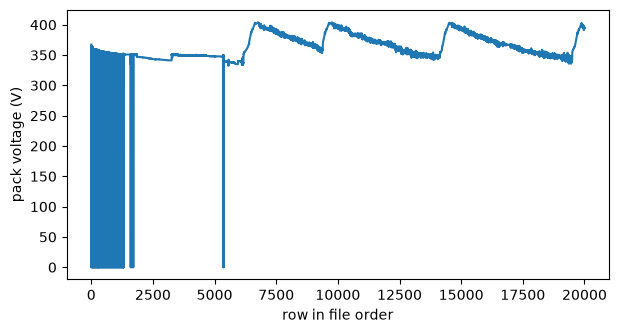

In [4]:
ax = frame['totalvoltage'].plot(figsize=(7, 3.5))
ax.set_xlabel('row in file order')
ax.set_ylabel('pack voltage (V)')
plt.show()

In the first 5,000 rows pack voltage often reads 0 V, where the whole BMS block is zero in the release (see the schema file, `clean=True` masks these). After that the file shows charges to about 400 V and falling voltage while driving. File order is used because `terminaltime` is not sorted in the release.